In [1]:
import sys
import os

print("Interprete Python:", sys.executable)
print("Prefijo (sys.prefix):", sys.prefix)
print("Entorno conda:", os.environ.get("CONDA_DEFAULT_ENV"))


Interprete Python: /data/home/rtabares/anaconda3/envs/autosklearn_py39/bin/python
Prefijo (sys.prefix): /data/home/rtabares/anaconda3/envs/autosklearn_py39
Entorno conda: autosklearn_py39


# **HEART DISEASE**

Detected classes:
  0 → <50% narrowing (no disease)
  1 → 50–75% narrowing
  2 → 75–90% narrowing
  3 → 90–99% narrowing
  4 → 100% occlusion (total occlusion)

Training deep MLP (this may take a while)…


/data/home/rtabares/anaconda3/envs/llmxai/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Iteration 1, loss = 1.65144504
Iteration 2, loss = 1.56513836
Iteration 3, loss = 1.48526903
Iteration 4, loss = 1.38699799
Iteration 5, loss = 1.27056018
Iteration 6, loss = 1.15502649
Iteration 7, loss = 1.04935757
Iteration 8, loss = 0.96452515
Iteration 9, loss = 0.89730588
Iteration 10, loss = 0.83064387
Iteration 11, loss = 0.75688867
Iteration 12, loss = 0.69693240
Iteration 13, loss = 0.63649820
Iteration 14, loss = 0.57671565
Iteration 15, loss = 0.51689284
Iteration 16, loss = 0.46540100
Iteration 17, loss = 0.43242179
Iteration 18, loss = 0.38235525
Iteration 19, loss = 0.34646182
Iteration 20, loss = 0.31894939
Iteration 21, loss = 0.27933017
Iteration 22, loss = 0.25171545
Iteration 23, loss = 0.22691672
Iteration 24, loss = 0.20286166
Iteration 25, loss = 0.17731257
Iteration 26, loss = 0.16156888
Iteration 27, loss = 0.15026794
Iteration 28, loss = 0.13664853
Iteration 29, loss = 0.12120049
Iteration 30, loss = 0.11222301
Iteration 31, loss = 0.10273890
Iteration 32, los

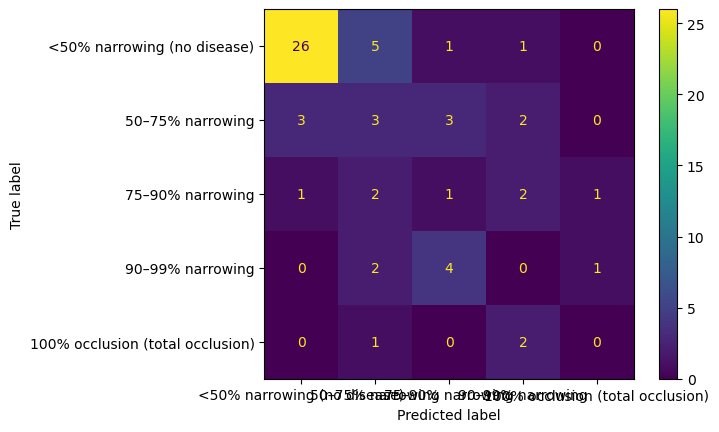

In [2]:
import glob
from pathlib import Path

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import joblib

# ────────────────────────────────────────────────────────
# 1) Load data
# ────────────────────────────────────────────────────────
matches = glob.glob("**/processed.cleveland.data", recursive=True)
if not matches:
    raise FileNotFoundError("processed.cleveland.data not found")
data_path = Path(matches[0])

column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]
df = pd.read_csv(
    data_path,
    header=None,
    names=column_names,
    na_values="?"
)

# ────────────────────────────────────────────────────────
# 2) Class mapping (optional)
# ────────────────────────────────────────────────────────
class_mapping = {
    0: "<50% narrowing (no disease)",
    1: "50–75% narrowing",
    2: "75–90% narrowing",
    3: "90–99% narrowing",
    4: "100% occlusion (total occlusion)"
}
print("Detected classes:")
for v in sorted(df.target.unique()):
    print(f"  {v} → {class_mapping[v]}")

# ────────────────────────────────────────────────────────
# 3) Train/test split
# ────────────────────────────────────────────────────────
X = df.drop(columns="target")
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ────────────────────────────────────────────────────────
# 4) Build pipeline with deep MLP
# ────────────────────────────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32, 16),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size="auto",
    learning_rate="adaptive",
    learning_rate_init=1e-3,
    max_iter=2000,
    tol=1e-5,
    verbose=True,
    random_state=42
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", mlp),
])

print("\nTraining deep MLP (this may take a while)…")
pipeline.fit(X_train, y_train)

# ────────────────────────────────────────────────────────
# 5) Evaluate on test
# ────────────────────────────────────────────────────────
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest accuracy: {acc:.3%}")

cm = confusion_matrix(y_test, y_pred, labels=list(class_mapping.keys()))
disp = ConfusionMatrixDisplay(cm, display_labels=[class_mapping[i] for i in class_mapping])
disp.plot()

# ────────────────────────────────────────────────────────
# 6) Save pipeline
# ────────────────────────────────────────────────────────
out_path = Path("./Heart_Disease/MODEL/mlp_deep_pipeline.joblib")
out_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(pipeline, out_path)
print(f"\n✅ Pipeline saved to: {out_path}")


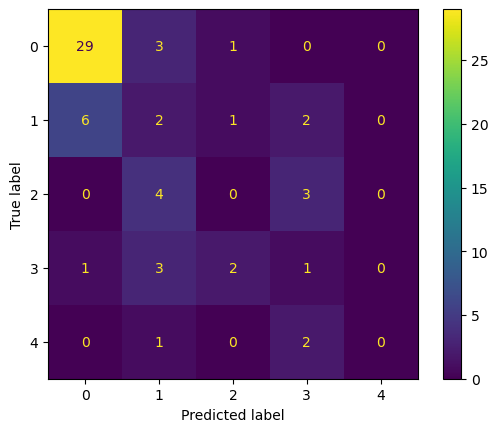

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
y_pred = best_pipeline.predict(X_test_imp)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_mapping)
disp.plot()


# **Thyroid Cancer Recurrence**

In [3]:
!ls

AIDS_Clinical_Trials	       Heart_Failure_Clinical
Breast_Cancer_Wisconsin        Hepatitis
CDC_Diabetes		       Lung_Cancer
Cervical_Cancer		       Mammographic_Mass
Chronic_Kidney_Disease	       Maternal_Health_Risk
Cirrhosis_Patient_Survival     NPHA
Diabetes_130_US		       Obesity_Levels
Diabetic_Retinopathy_Debrecen  Thoracic_Surgery_Data
Fertility		       Thyroid_Cancer_Recurrence
Glioma_Grading_Clinical        Thyroid_Disease
HCV_data		       Train.ipynb
Heart_Disease


[WARNING] [2025-06-19 09:04:58,393:Client-EnsembleBuilder] No runs were available to build an ensemble from
[WARNING] [2025-06-19 09:04:58,759:Client-EnsembleBuilder] No runs were available to build an ensemble from

Accuracy en test: 96.104%
✅ Pipeline completo exportado a: ./Thyroid_Cancer_Recurrence/MODEL/automl_thyroid.joblib
✅ Mejor pipeline exportado a: ./Thyroid_Cancer_Recurrence/MODEL/best_thyroid_pipeline.joblib


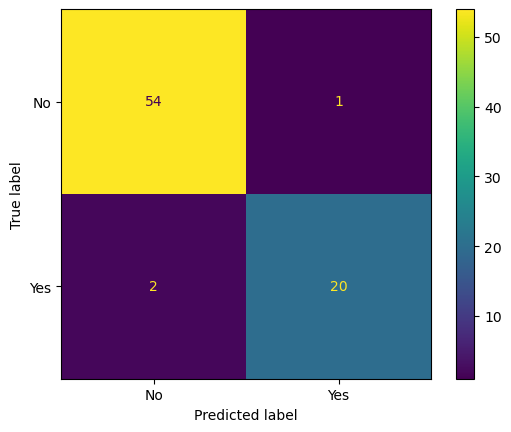

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTE
from autosklearn.classification import AutoSklearnClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

# ────────────────────────────────────────────────────────
# 1) Carga de datos
# ────────────────────────────────────────────────────────
data_path = Path("./Thyroid_Cancer_Recurrence/DATASET/Thyroid_Diff.csv")
df = pd.read_csv(data_path)

# ────────────────────────────────────────────────────────
# 2) Creación de target binario
# ────────────────────────────────────────────────────────
df["target"] = df["Recurred"].map({"No": 0, "Yes": 1})
df.drop(columns=["Recurred"], inplace=True)

# ────────────────────────────────────────────────────────
# 3) División Train/Test
# ────────────────────────────────────────────────────────
X = df.drop(columns=["target"])
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ────────────────────────────────────────────────────────
# 4) Codificación ordinal de categóricas
# ────────────────────────────────────────────────────────
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

enc = OrdinalEncoder()
# Fit sobre train categórico
X_train_cat = enc.fit_transform(X_train[cat_cols])
X_test_cat  = enc.transform(X_test[cat_cols])

# Extraemos los numéricos sin cambios
X_train_num = X_train[num_cols].to_numpy()
X_test_num  = X_test[num_cols].to_numpy()

# Concatenamos numéricos + categóricos codificados
X_train_enc = np.hstack([X_train_num, X_train_cat])
X_test_enc  = np.hstack([X_test_num,  X_test_cat])

# ────────────────────────────────────────────────────────
# 5) Balanceo con SMOTE
# ────────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_enc, y_train)

# ────────────────────────────────────────────────────────
# 6) Entrenamiento AutoSklearnClassifier
# ────────────────────────────────────────────────────────
automl = AutoSklearnClassifier(
    time_left_for_this_task=900,              # 60 min en total
    per_run_time_limit=300,                    #  5 min/configuración
    resampling_strategy="holdout",
    resampling_strategy_arguments={"train_size": 0.75},
    dataset_compression=False,
    initial_configurations_via_metalearning=50,
    ensemble_kwargs={"ensemble_size": 50},
    memory_limit=None,                         #  8 GB por job
    n_jobs=8,
    seed=42,
)
automl.fit(X_res, y_res)

# ────────────────────────────────────────────────────────
# 7) Evaluación y matriz de confusión
# ────────────────────────────────────────────────────────
accuracy = automl.score(X_test_enc, y_test)
print(f"\nAccuracy en test: {accuracy:.3%}")

y_pred = automl.predict(X_test_enc)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()

# ────────────────────────────────────────────────────────
# 8) Exportar pipelines
# ────────────────────────────────────────────────────────
output_full = "./Thyroid_Cancer_Recurrence/MODEL/automl_thyroid.joblib"
joblib.dump(automl, output_full)
print(f"✅ Pipeline completo exportado a: {output_full}")

weight, best_pipeline = automl.get_models_with_weights()[0]
output_best = "./Thyroid_Cancer_Recurrence/MODEL/best_thyroid_pipeline.joblib"
joblib.dump(best_pipeline, output_best)
print(f"✅ Mejor pipeline exportado a: {output_best}")


In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

# 1) Vuelve a cargar tu training set original
df = pd.read_csv("./Thyroid_Cancer_Recurrence/DATASET/Thyroid_Diff.csv")
df["target"] = df["Recurred"].map({"No":0,"Yes":1})
df.drop(columns=["Recurred"], inplace=True)
X_train = df.drop(columns=["target"])
y_train = df["target"]

# 2) Define columnas
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

# 3) Crea y FIT del ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num_imputer", SimpleImputer(strategy="median"), num_cols),
    ("cat_encoder", Pipeline([
        ("imputer_cat", SimpleImputer(strategy="most_frequent")),
        ("ordinal_enc", OrdinalEncoder())
    ]), cat_cols)
])
preprocessor.fit(X_train)    # <— aquí fiteas

# 4) Carga tu modelo ya entrenado de Auto-sklearn
automl_model = joblib.load("./Thyroid_Cancer_Recurrence/MODEL/best_thyroid_pipeline.joblib")

# 5) Combina y guarda
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("automl",      automl_model)
])
joblib.dump(full_pipeline, "./Thyroid_Cancer_Recurrence/MODEL/full_thyroid_pipeline.joblib")


['./Thyroid_Cancer_Recurrence/MODEL/full_thyroid_pipeline.joblib']

In [9]:
import pandas as pd
import joblib

# 1) Carga cruda
df_nuevos_datos = pd.read_csv(
    "./Thyroid_Cancer_Recurrence/DATASET/Thyroid_Diff.csv"
)

# 2) Elimina las columnas que no entrenaste:
#    - 'Recurred' (usada para crear el target)
#    - 'target'   (si existe)
cols_a_quitar = ["Recurred", "target"]
X_new = df_nuevos_datos.drop(columns=cols_a_quitar, errors="ignore")

# 3) Carga tu pipeline ya completo (preprocesador + Auto-sklearn)
full_pipeline = joblib.load(
    "./Thyroid_Cancer_Recurrence/MODEL/full_thyroid_pipeline.joblib"
)

# 4) Ahora sí predice sobre sólo las 16 columnas esperadas
preds = full_pipeline.predict(X_new)
print(preds)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [10]:
import joblib
import pandas as pd
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────
# 1) Carga tu AutoSklearnClassifier entrenado
# ────────────────────────────────────────────────────────
automl = joblib.load(
    "./Thyroid_Cancer_Recurrence/MODEL/automl_thyroid.joblib"
)

# ────────────────────────────────────────────────────────
# 2) Extrae el mejor sub-pipeline (fitted transformers + config)
# ────────────────────────────────────────────────────────
_, best_pipeline = automl.get_models_with_weights()[0]
config = best_pipeline.config.get_dictionary()

# ────────────────────────────────────────────────────────
# 3) Extrae el ColumnTransformer de sklearn que Auto-sklearn usó
# ────────────────────────────────────────────────────────
# DataPreprocessorChoice.choice.column_transformer es un sklearn ColumnTransformer
data_prep_wrapper = best_pipeline.named_steps["data_preprocessor"]
column_transformer = data_prep_wrapper.choice.column_transformer

# ────────────────────────────────────────────────────────
# 4) Extrae el feature_preprocessor puro de sklearn
# ────────────────────────────────────────────────────────
feat_prep_wrapper = best_pipeline.named_steps["feature_preprocessor"]
feat_transformer = feat_prep_wrapper.choice  # Ej: PolynomialFeatures, PCA, SelectPercentile...

# ────────────────────────────────────────────────────────
# 5) Reconstruye el clf puro de sklearn (igual que antes)
# ────────────────────────────────────────────────────────
clf_choice = config["classifier:__choice__"]
clf_prefix = f"classifier:{clf_choice}:"
clf_params = {
    key.split(":", 2)[-1]: value
    for key, value in config.items()
    if key.startswith(clf_prefix)
}

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import PassiveAggressiveClassifier, SGDClassifier
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

if clf_choice == "random_forest":
    clf = RandomForestClassifier(**clf_params, random_state=42, n_jobs=-1)
elif clf_choice == "gradient_boosting":
    clf = GradientBoostingClassifier(**clf_params, random_state=42)
elif clf_choice == "hist_gradient_boosting":
    clf = HistGradientBoostingClassifier(**clf_params, random_state=42)
elif clf_choice == "adaboost":
    clf = AdaBoostClassifier(**clf_params, random_state=42)
elif clf_choice == "bernoulli_nb":
    clf = BernoulliNB(**clf_params)
elif clf_choice == "gaussian_nb":
    clf = GaussianNB(**clf_params)
elif clf_choice == "multinomial_nb":
    clf = MultinomialNB(**clf_params)
elif clf_choice == "decision_tree":
    clf = DecisionTreeClassifier(**clf_params, random_state=42)
elif clf_choice == "k_nearest_neighbors":
    clf = KNeighborsClassifier(**clf_params)
elif clf_choice == "lda":
    clf = LinearDiscriminantAnalysis(**clf_params)
elif clf_choice == "qda":
    clf = QuadraticDiscriminantAnalysis(**clf_params)
elif clf_choice == "passive_aggressive":
    clf = PassiveAggressiveClassifier(**clf_params, random_state=42)
elif clf_choice == "sgd":
    clf = SGDClassifier(**clf_params, random_state=42)
elif clf_choice in ["liblinear_svc", "libsvm_svc"]:
    clf = SVC(**clf_params, probability=True, random_state=42)
elif clf_choice == "mlp":
    clf = MLPClassifier(**clf_params, random_state=42)
else:
    raise ValueError(f"Estimador '{clf_choice}' no soportado")

# ────────────────────────────────────────────────────────
# 6) Monta el Pipeline 100% sklearn
# ────────────────────────────────────────────────────────
manual_pipeline = Pipeline([
    ("preprocessor",   column_transformer),
    ("feature_preproc", feat_transformer),
    ("classifier",     clf)
])

# ────────────────────────────────────────────────────────
# 7) Guarda tu pipeline puro sklearn
# ────────────────────────────────────────────────────────
joblib.dump(
    manual_pipeline,
    "./Thyroid_Cancer_Recurrence/MODEL/manual_sklearn_pipeline.joblib"
)
print("✅ Manual sklearn pipeline guardado en 'manual_sklearn_pipeline.joblib'")

# ────────────────────────────────────────────────────────
# 8) Prueba en tu test set
# ────────────────────────────────────────────────────────
# 8.1) Carga y prepara datos
df = pd.read_csv("./Thyroid_Cancer_Recurrence/DATASET/Thyroid_Diff.csv")
df["target"] = df["Recurred"].map({"No": 0, "Yes": 1})
df.drop(columns=["Recurred"], inplace=True)
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 8.2) Predict y métricas
y_pred = manual_pipeline.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
print(f"\nAccuracy en test: {acc:.3%}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión – Manual Pipeline")
plt.show()


✅ Manual sklearn pipeline guardado en 'manual_sklearn_pipeline.joblib'


ValueError: Cannot use mean strategy with non-numeric data:
could not convert string to float: 'M'

In [7]:
from pprint import pprint

for name, step in manual_pipeline.steps:
    cls = step.__class__
    module = cls.__module__
    print(f"Paso: {name}")
    print(f"  Clase: {cls.__name__}")
    print(f"  Módulo: {module}")
    print("  ¿Es de scikit-learn?", module.startswith("sklearn"))
    print()


Paso: imputer
  Clase: SimpleImputer
  Módulo: sklearn.impute._base
  ¿Es de scikit-learn? True

Paso: scaler
  Clase: StandardScaler
  Módulo: sklearn.preprocessing._data
  ¿Es de scikit-learn? True

Paso: feature_preprocessor
  Clase: FunctionTransformer
  Módulo: sklearn.preprocessing._function_transformer
  ¿Es de scikit-learn? True

Paso: classifier
  Clase: RandomForestClassifier
  Módulo: sklearn.ensemble._forest
  ¿Es de scikit-learn? True



In [11]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1) Carga tu encoder y tu pipeline
enc            = joblib.load("./Thyroid_Cancer_Recurrence/MODEL/ordinal_encoder.joblib")
manual_pipe    = joblib.load("./Thyroid_Cancer_Recurrence/MODEL/manual_sklearn_pipeline.joblib")

# 2) Carga y prepara los datos crudos
df = pd.read_csv("./Thyroid_Cancer_Recurrence/DATASET/Thyroid_Diff.csv")
df["target"] = df["Recurred"].map({"No":0, "Yes":1})
df.drop(columns=["Recurred"], inplace=True)

X = df.drop(columns=["target"])
y = df["target"]

# 3) Reproduce exactamente el train_test_split
from sklearn.model_selection import train_test_split
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4) Ordinal encode de nuevo las categóricas
cat_cols = X.select_dtypes(include="object").columns
num_cols = [c for c in X.columns if c not in cat_cols]

X_test_num = X_test[num_cols].to_numpy()
X_test_cat = enc.transform(X_test[cat_cols])
X_test_enc = np.hstack([X_test_num, X_test_cat])

# 5) Ahora sí predict y métricas
y_pred = manual_pipe.predict(X_test_enc)
print(f"\nAccuracy en test: {accuracy_score(y_test, y_pred):.3%}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No","Yes"])
disp.plot()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: './Thyroid_Cancer_Recurrence/MODEL/ordinal_encoder.joblib'

/data/home/rtabares/anaconda3/envs/llmxai/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



Accuracy en test: 96.104%


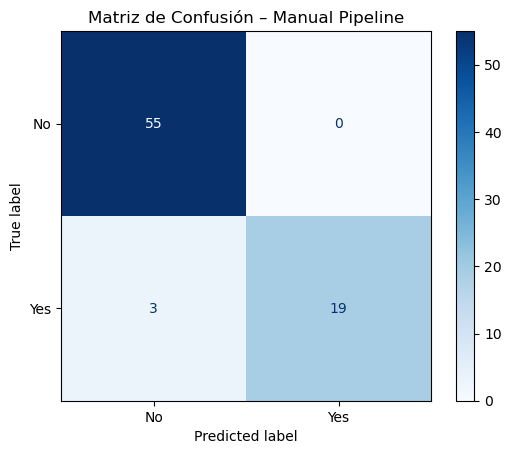

✅ Pipeline guardado en: ./Thyroid_Cancer_Recurrence/MODEL/manual_sklearn_pipeline.joblib


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────
# 1) Carga de datos
# ────────────────────────────────────────────────────────
data_path = Path("./Thyroid_Cancer_Recurrence/DATASET/Thyroid_Diff.csv")
df = pd.read_csv(data_path)

# ────────────────────────────────────────────────────────
# 2) Creación de target binario
# ────────────────────────────────────────────────────────
df["target"] = df["Recurred"].map({"No": 0, "Yes": 1})
df.drop(columns=["Recurred"], inplace=True)

# ────────────────────────────────────────────────────────
# 3) División train/test
# ────────────────────────────────────────────────────────
X = df.drop(columns=["target"])
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ────────────────────────────────────────────────────────
# 4) Preprocesamiento
# ────────────────────────────────────────────────────────
# Identifica columnas numéricas y categóricas
numeric_cols     = ["Age"]
categorical_cols = [c for c in X.columns if c not in numeric_cols]

# Pipelines separados
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",   StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,     numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

# ────────────────────────────────────────────────────────
# 5) Pipeline completo con SMOTE + clasificador
# ────────────────────────────────────────────────────────
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("smote",        SMOTE(random_state=42)),
    ("classifier",   RandomForestClassifier(
                         n_estimators=200,
                         random_state=42,
                         n_jobs=-1
                     )),
])

# ────────────────────────────────────────────────────────
# 6) Entrenamiento
# ────────────────────────────────────────────────────────
pipe.fit(X_train, y_train)

# ────────────────────────────────────────────────────────
# 7) Evaluación
# ────────────────────────────────────────────────────────
y_pred = pipe.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
print(f"\nAccuracy en test: {acc:.3%}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión – Manual Pipeline")
plt.show()

# ────────────────────────────────────────────────────────
# 8) Guardado del pipeline
# ────────────────────────────────────────────────────────
output_path = "./Thyroid_Cancer_Recurrence/MODEL/manual_sklearn_pipeline.joblib"
joblib.dump(pipe, output_path)
print(f"✅ Pipeline guardado en: {output_path}")
